# Mock Feedback-Shadow Tomography: 3-Qubit Cluster State

This notebook simulates the full feedback-shadow measurement pipeline:
1. **State prep**: 3-qubit cluster state |ψ⟩ = ∏ CZ |+++⟩
2. **Ancilla biasing**: Ry rotations on 2 ancillas per data qubit (6 ancillas total → 9 qubits)
3. **Feedback loop**: Measure ancillas, apply conditional Ry/Rx on data qubits
4. **Measurement**: Measure data qubits in rotated basis
5. **Reconstruction**: Use ShadowProcessor to recover ρ

**Goal**: Diagnose off-diagonal contrast issue with full visibility into each step.

In [1]:
! pip install --upgrade qiskit-aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.5 MB ? eta -:--:--Downloading qiskit_aer-0.17.2-cp312-cp312-macosx_10_13_x86_64.whl (2.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 8.8 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 8.8 MB/s eta 0:00:00
  Attempting uninstall: qiskit-aer
  Attempting uninstall: qiskit-aer
    Found existing installation: qiskit-aer 0.15.0
    Uninstalling qiskit-aer-0.15.0:
      Successfully uninstalled qiskit-aer-0.15.0
    Found existing installation: qiskit-aer 0.15.0
    Uninstalling qiskit-aer-0.15.0:
      Successfully uninstalled qiskit-aer-0.15.0


In [5]:
import sys, os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Setup path
repo_root = os.path.abspath('../..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from shadow_gym.src.quantum_environment import QuantumEnvironment
from shadow_gym.src.shadow_processor import ShadowProcessor

print("Imports successful. Ready to build 3-qubit feedback-shadow simulator.")

Imports successful. Ready to build 3-qubit feedback-shadow simulator.


## 1. Prepare Ideal 3-Qubit Cluster State

Ideal 3-qubit cluster state prepared
  Statevector shape: (8,)
  Density matrix shape: (8, 8)
  Trace: 1.000000+0.000000j
  Purity: 1.000000+0.000000j


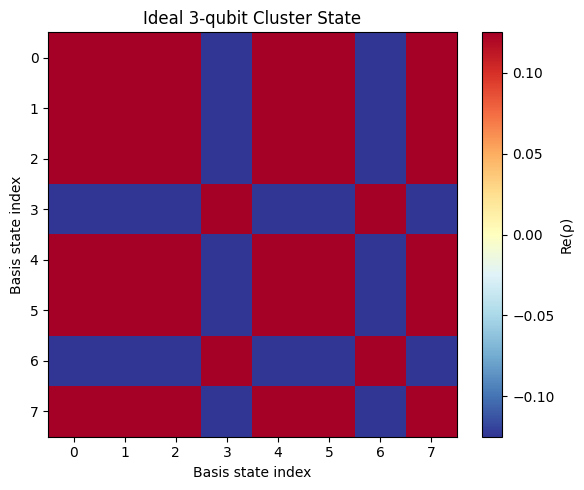

In [6]:
n_data = 3
env = QuantumEnvironment(n_data=n_data)
sv_ideal = env.prepare_cluster_state(depolarizing_p=0.0)
rho_ideal = env.rho_true

print(f"Ideal {n_data}-qubit cluster state prepared")
print(f"  Statevector shape: {sv_ideal.shape}")
print(f"  Density matrix shape: {rho_ideal.shape}")
print(f"  Trace: {np.trace(rho_ideal):.6f}")
print(f"  Purity: {np.trace(rho_ideal @ rho_ideal):.6f}")

# Visualize ideal ρ
plt.figure(figsize=(6, 5))
plt.imshow(np.real(rho_ideal), cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='Re(ρ)')
plt.title(f'Ideal {n_data}-qubit Cluster State')
plt.xlabel('Basis state index')
plt.ylabel('Basis state index')
plt.tight_layout()
plt.show()

## 2. Simulate Feedback-Shadow Measurement

For each shot:
1. Sample 2 ancilla outcomes per data qubit (uniformly)
2. Apply conditional Ry/Rx rotations to data qubits based on ancilla outcomes
3. Measure data qubits in the rotated basis
4. Decode basis labels from ancilla outcomes

In [7]:
def softmax_to_angles(px: float, py: float, pz: float):
    """
    Compute ancilla bias angles from desired basis probabilities (px, py, pz).
    Uses the formula from act1_shadow_tomography.ipynb.
    
    The ancilla measurement outcomes determine the basis:
      (0,0) → Z with prob p1*(1-p2)
      (1,0) → X with prob (1-p1)*p2
      (0,1) → Y with prob p1*p2
      (1,1) → Y with prob (1-p1)*(1-p2)
    
    Conversely: Tr(Py*ρ) ~ P(Y) where P(Y) = p1*p2 + (1-p1)*(1-p2)
    
    Formula from act1_shadow_tomography:
      - p2 = py  (directly set P(Y))
      - p1 = px / (px + pz)  (ratio of X to Z among non-Y outcomes)
    """
    # Normalize input probabilities
    total = px + py + pz
    px, py, pz = px / total, py / total, pz / total
    
    # p2 directly controls the total probability of measuring Y
    p2 = py
    
    # p1 distributes the REMAINING probability between X and Z
    # p1 = px / (px + pz)  gives equal weight if px = pz
    p1 = px / (px + pz + 1e-12)
    
    # Clamp to [0, 1]
    p1 = np.clip(p1, 0, 1)
    p2 = np.clip(p2, 0, 1)
    
    # Convert probabilities to angles: p = sin²(θ/2)  →  θ = 2*arcsin(√p)
    theta1 = 2.0 * np.arcsin(np.sqrt(p1))
    theta2 = 2.0 * np.arcsin(np.sqrt(p2))
    
    return theta1, theta2

theta1, theta2 = softmax_to_angles(1/3, 1/3, 1/3)
print(f"\nAncilla bias angles for uniform Z/X/Y distribution:")
print(f"  θ1 = {np.degrees(theta1):.1f}°  (sin²(θ1/2) = {np.sin(theta1/2)**2:.4f})")
print(f"  θ2 = {np.degrees(theta2):.1f}°  (sin²(θ2/2) = {np.sin(theta2/2)**2:.4f})")

# Verify the basis probabilities with these angles
p1 = np.sin(theta1/2) ** 2
p2 = np.sin(theta2/2) ** 2
prob_z = p1 * (1 - p2)
prob_x = (1 - p1) * p2
prob_y = p1 * p2 + (1 - p1) * (1 - p2)
print(f"\nResulting basis probabilities:")
print(f"  P(Z) = {prob_z:.4f}")
print(f"  P(X) = {prob_x:.4f}")
print(f"  P(Y) = {prob_y:.4f}")
print(f"  Total = {prob_z + prob_x + prob_y:.4f}")



Ancilla bias angles for uniform Z/X/Y distribution:
  θ1 = 90.0°  (sin²(θ1/2) = 0.5000)
  θ2 = 70.5°  (sin²(θ2/2) = 0.3333)

Resulting basis probabilities:
  P(Z) = 0.3333
  P(X) = 0.1667
  P(Y) = 0.5000
  Total = 1.0000


In [8]:

# ── Build and Simulate Feedback-Shadow Circuit ───────────────────────────────
"""
Build a 3-qubit feedback-shadow circuit with:
1. Ancilla biasing (Ry rotations)
2. Mid-circuit measurement of ancillas
3. Cluster state preparation
4. Conditional CRy/CRx feedback based on ancilla outcomes
5. Final measurement of data qubits

We'll use a 9-qubit system: 3 data + 6 ancillas (2 per data qubit)
"""

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator

def build_feedback_shadow_circuit_qiskit(theta1: float, theta2: float, n_data: int = 3) -> QuantumCircuit:
    """
    Build a feedback-shadow measurement circuit on n_data qubits with ancillas.
    
    Layout: qubits 0-2 = data, qubits 3-8 = ancillas (2 per data qubit)
    """
    n_ancillas = 2 * n_data
    qr_data = QuantumRegister(n_data, 'data')
    qr_anc = QuantumRegister(n_ancillas, 'anc')
    cr_all = ClassicalRegister(n_data + n_ancillas, 'c_all')
    
    qc = QuantumCircuit(qr_data, qr_anc, cr_all, name='feedback_shadow')
    
    # ── Stage 1: Ancilla biasing (Ry rotations) ────────────────────────────
    for i in range(n_data):
        qc.ry(theta1, qr_anc[2*i])      # A1 for data qubit i
        qc.ry(theta2, qr_anc[2*i + 1])  # A2 for data qubit i
    qc.barrier()
    
    # ── Stage 2: Mid-circuit measurement of ancillas ────────────────────────
    # Measure ancillas into classical register c_all[n_data : n_data + n_ancillas]
    for i in range(n_data):
        qc.measure(qr_anc[2*i], cr_all[n_data + 2*i])           # A1
        qc.measure(qr_anc[2*i + 1], cr_all[n_data + 2*i + 1])   # A2
    qc.barrier()
    
    # ── Stage 3: Cluster state preparation ────────────────────────────────
    for i in range(n_data):
        qc.h(qr_data[i])
    for i in range(n_data - 1):
        qc.cz(qr_data[i], qr_data[i+1])
    qc.barrier()
    
    # ── Stage 4: Conditional rotations (feedback based on ancilla outcomes) ──
    # Controlled by measured ancilla bits via dynamic circuits
    for i in range(n_data):
        # CRy(-π/2) controlled by A1: if a1=1, rotate data[i] by -π/2 (→ X basis)
        qc.cry(-np.pi / 2, qr_anc[2*i], qr_data[i])
        # CRx(+π/2) controlled by A2: if a2=1, rotate data[i] by +π/2 (→ Y basis)
        qc.crx(np.pi / 2, qr_anc[2*i + 1], qr_data[i])
    qc.barrier()
    
    # ── Stage 5: Measure data qubits ─────────────────────────────────────
    for i in range(n_data):
        qc.measure(qr_data[i], cr_all[i])
    
    return qc

# Build and simulate one circuit
qc_feedback = build_feedback_shadow_circuit_qiskit(theta1, theta2, n_data)
print(f"Feedback-shadow circuit depth: {qc_feedback.depth()}")
print(f"Total qubits: {qc_feedback.num_qubits}")
print(f"Classical bits: {qc_feedback.num_clbits}")
print("\nCircuit structure:")
print(qc_feedback.draw(output='text', fold=120, idle_wires=False))


Feedback-shadow circuit depth: 8
Total qubits: 9
Classical bits: 9

Circuit structure:
                       ░                    ░ ┌───┐       ░ ┌──────────┐                        ┌─────────┐           »
 data_0: ──────────────░────────────────────░─┤ H ├─■─────░─┤ Ry(-π/2) ├────────────────────────┤ Rx(π/2) ├───────────»
                       ░                    ░ ├───┤ │     ░ └────┬─────┘┌──────────┐            └────┬────┘┌─────────┐»
 data_1: ──────────────░────────────────────░─┤ H ├─■──■──░──────┼──────┤ Ry(-π/2) ├─────────────────┼─────┤ Rx(π/2) ├»
                       ░                    ░ ├───┤    │  ░      │      └────┬─────┘┌──────────┐     │     └────┬────┘»
 data_2: ──────────────░────────────────────░─┤ H ├────■──░──────┼───────────┼──────┤ Ry(-π/2) ├─────┼──────────┼─────»
          ┌─────────┐  ░ ┌─┐                ░ └───┘       ░      │           │      └────┬─────┘     │          │     »
  anc_0: ─┤ Ry(π/2) ├──░─┤M├────────────────░─────────────░──────■───────

In [28]:
import numpy as np
from qiskit import QuantumCircuit

# 1. Define the QND basis labels
QND_BASIS_LABELS = {
    (0, 0): "Z", 
    (1, 0): "X", 
    (0, 1): "Y", 
    (1, 1): "Y"  # The diagonal outcome maps effectively to Y
}

# ── Run Circuit Simulation ───────────────────────────────────────────────────
"""
Simulate the feedback-shadow circuit and extract (basis, outcome) pairs.
Compare with the statevector-only sampling approach.
"""

from qiskit_aer import AerSimulator
from qiskit import transpile

# Use AerSimulator (local statevector simulator)
simulator = AerSimulator(method='statevector')

# Transpile for the simulator
qc_transpiled = transpile(qc_feedback, simulator, optimization_level=2)

# Run simulation with 5000 shots
print("Running circuit simulation (5000 shots)...")
job = simulator.run(qc_transpiled, shots=10000, memory=True)
result = job.result()
memory = result.get_memory(0)  # Get all bitstrings

print(f"Generated {len(memory)} bitstrings from circuit simulation")
print(f"Sample bitstrings (first 5):")
for i in range(min(5, len(memory))):
    print(f"  {i}: {memory[i]}")

# ── Decode Circuit Bitstrings → (basis, outcome) ────────────────────────────
def decode_circuit_bitstring(bitstring: str, n_data: int = 3):
    """
    Decode a Qiskit memory bitstring into (basis_labels, data_outcomes).
    
    Register layout: c_all[0:n_data] = data outcomes, c_all[n_data:n_data+2*n_data] = ancilla outcomes
    Qiskit returns MSB-first: reverse to get LSB-first indexing.
    """
    bits_str = bitstring.strip().replace(" ", "")
    total_bits = n_data + 2 * n_data
    
    if len(bits_str) != total_bits:
        raise ValueError(f"Expected {total_bits} bits, got {len(bits_str)}: {bitstring}")
    
    # Reverse for LSB-first indexing
    bits_reversed = bits_str[::-1]
    
    # Extract data bits: c_all[0:n_data]
    data_bits = bits_reversed[:n_data]
    
    # Extract ancilla bits: c_all[n_data:n_data+2*n_data]
    anc_bits = bits_reversed[n_data:n_data + 2*n_data]
    
    # Decode basis from ancilla pairs
    basis_labels = []
    outcomes = []
    
    for i in range(n_data):
        a1_bit = int(anc_bits[2*i])
        a2_bit = int(anc_bits[2*i + 1])
        ancilla_pair = (a1_bit, a2_bit)
        
        basis = QND_BASIS_LABELS.get(ancilla_pair, 'Z')  # Default to Z if not found
        basis_labels.append(basis)
        
        data_bit = int(data_bits[i])
        outcomes.append(data_bit)
    
    return basis_labels, outcomes

# Decode all bitstrings
circuit_shadows = []
for bitstring in memory:
    try:
        basis_labels, outcomes = decode_circuit_bitstring(bitstring, n_data)
        circuit_shadows.append((basis_labels, outcomes))
    except Exception as e:
        print(f"Error decoding '{bitstring}': {e}")

print(f"\nDecoded {len(circuit_shadows)} shots")
print("Sample decoded shots (first 5):")
for i in range(min(5, len(circuit_shadows))):
    basis, outcome = circuit_shadows[i]
    print(f"  Shot {i}: basis={basis}, outcome={outcome}")

# ── Compare Circuit vs. Statevector Basis Distributions ────────────────────
print(f"\n{'='*60}")
print("Basis Distribution Comparison")
print(f"{'='*60}")

from collections import Counter

# Circuit simulation
circuit_basis_counts = [Counter() for _ in range(n_data)]
for basis, _ in circuit_shadows:
    for i, b in enumerate(basis):
        circuit_basis_counts[i][b] += 1


print("\nPer-qubit basis distribution:")
print(f"{'Qubit':<8} {'Method':<15} {'Z':<10} {'X':<10} {'Y':<10} {'D':<10}")
print("-" * 60)

for i in range(n_data):
    for method_name, counts in [("Circuit", circuit_basis_counts[i]), ("Statevector", statevec_basis_counts[i])]:
        total = sum(counts.values())
        z_pct = 100 * counts.get('Z', 0) / total if total > 0 else 0
        x_pct = 100 * counts.get('X', 0) / total if total > 0 else 0
        y_pct = 100 * counts.get('Y', 0) / total if total > 0 else 0
        d_pct = 100 * counts.get('D', 0) / total if total > 0 else 0
        print(f"Q{i:<7} {method_name:<15} {z_pct:>8.1f}% {x_pct:>8.1f}% {y_pct:>8.1f}% {d_pct:>8.1f}%")
    print()

print(f"{'='*60}")
print("✓ Circuit simulation complete. Use circuit_shadows for reconstruction.")


Running circuit simulation (5000 shots)...
Generated 10000 bitstrings from circuit simulation
Sample bitstrings (first 5):
  0: 101011100
  1: 101100101
  2: 110111111
  3: 100111100
  4: 010001000

Decoded 10000 shots
Sample decoded shots (first 5):
  Shot 0: basis=['Y', 'Y', 'Y'], outcome=[0, 0, 1]
  Shot 1: basis=['Z', 'Y', 'Y'], outcome=[1, 0, 1]
  Shot 2: basis=['Y', 'X', 'Y'], outcome=[1, 1, 1]
  Shot 3: basis=['Y', 'X', 'Y'], outcome=[0, 0, 1]
  Shot 4: basis=['X', 'Z', 'X'], outcome=[0, 0, 0]

Basis Distribution Comparison

Per-qubit basis distribution:
Qubit    Method          Z          X          Y          D         
------------------------------------------------------------
Q0       Circuit             32.5%     33.8%     33.8%      0.0%
Q0       Statevector          0.0%      0.0%      0.0%      0.0%

Q1       Circuit             33.6%     33.8%     32.6%      0.0%
Q1       Statevector          0.0%      0.0%      0.0%      0.0%

Q2       Circuit             34.0%     3

In [9]:
def simulate_feedback_shadows(sv, n_qubits, theta1, theta2, n_shots=5000):
    """
    Simulate feedback-shadow measurement with biased ancillas:
    1. Sample ancilla outcomes according to Ry-rotated distribution
    2. Apply conditional rotations to data qubits
    3. Measure in the rotated basis
    4. Return (basis_labels, measurement_outcomes) tuples
    
    Parameters:
      sv: ideal statevector
      n_qubits: number of data qubits
      theta1, theta2: ancilla bias angles (Ry rotations)
      n_shots: number of measurement shots
    """
    from shadow_gym.src.utils import kron_n
    from shadow_gym.src.quantum_environment import QND_UNITARIES, QND_BASIS_LABELS
    
    # Compute ancilla excitation probabilities from bias angles
    p1 = np.sin(theta1/2) ** 2  # P(a1=1)
    p2 = np.sin(theta2/2) ** 2  # P(a2=1)
    
    results = []
    
    for shot in range(n_shots):
        # Step 1: Sample ancilla outcomes according to biased distribution
        ancilla_pairs = [
            (int(np.random.random() < p1), int(np.random.random() < p2))
            for _ in range(n_qubits)
        ]
        
        # Step 2: Get basis labels and unitaries from ancilla outcomes
        basis_labels = [QND_BASIS_LABELS[pair] for pair in ancilla_pairs]
        unitaries = [QND_UNITARIES[pair] for pair in ancilla_pairs]
        
        # Step 3: Apply unitaries to rotate statevector, then measure
        U_full = kron_n(*unitaries)  # Full N-qubit unitary
        sv_rotated = U_full @ sv
        
        # Compute measurement probabilities and sample outcome
        probs = np.abs(sv_rotated) ** 2
        basis_state_idx = np.random.choice(len(sv), p=probs)
        
        # Convert basis state index to qubit outcomes (big-endian: highest qubit = MSB)
        outcomes = [(basis_state_idx >> (n_qubits - 1 - i)) & 1 for i in range(n_qubits)]
        
        results.append((basis_labels, outcomes))
        
        if (shot + 1) % max(1, n_shots // 4) == 0 or shot + 1 == n_shots:
            print(f"  Shot {shot + 1} / {n_shots}")
    
    return results

print("Simulating feedback-shadow measurements with biased ancillas (5000 shots)...")
feedback_shadows = simulate_feedback_shadows(sv_ideal, n_data, theta1, theta2, n_shots=10000)
print(f"Generated {len(feedback_shadows)} shots")

# Show sample shots
print("\nSample shots:")
for i in range(3):
    basis, outcome = feedback_shadows[i]
    print(f"  Shot {i}: basis={basis}, outcome={outcome}")


Simulating feedback-shadow measurements with biased ancillas (5000 shots)...
  Shot 2500 / 10000
  Shot 5000 / 10000
  Shot 2500 / 10000
  Shot 5000 / 10000
  Shot 7500 / 10000
  Shot 10000 / 10000
Generated 10000 shots

Sample shots:
  Shot 0: basis=['Y', 'Z', 'Z'], outcome=[0, 0, 1]
  Shot 1: basis=['Z', 'X', 'X'], outcome=[1, 1, 0]
  Shot 2: basis=['X', 'Y', 'Z'], outcome=[1, 0, 1]
  Shot 7500 / 10000
  Shot 10000 / 10000
Generated 10000 shots

Sample shots:
  Shot 0: basis=['Y', 'Z', 'Z'], outcome=[0, 0, 1]
  Shot 1: basis=['Z', 'X', 'X'], outcome=[1, 1, 0]
  Shot 2: basis=['X', 'Y', 'Z'], outcome=[1, 0, 1]


## 3. Analyze Basis Distribution

Basis distribution per qubit:
  Q0: {'X': '33.2%', 'Y': '33.6%', 'Z': '33.2%'}
  Q1: {'X': '33.1%', 'Y': '33.0%', 'Z': '34.0%'}
  Q2: {'X': '33.2%', 'Y': '33.2%', 'Z': '33.5%'}


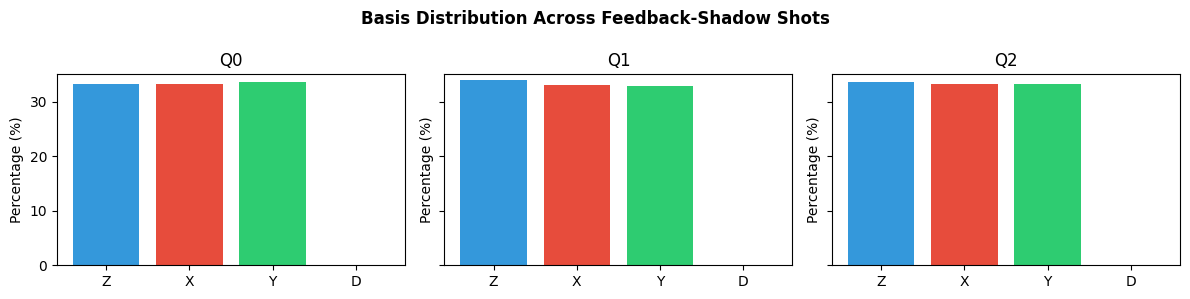

In [10]:
from collections import Counter

# Count basis distribution per qubit
basis_counts = [Counter() for _ in range(n_data)]
for basis, _ in feedback_shadows:
    for i, b in enumerate(basis):
        basis_counts[i][b] += 1

print("Basis distribution per qubit:")
for i, counts in enumerate(basis_counts):
    total = sum(counts.values())
    dist = {k: f"{100*v/total:.1f}%" for k, v in sorted(counts.items())}
    print(f"  Q{i}: {dist}")

# Plot histogram
fig, axes = plt.subplots(1, n_data, figsize=(12, 3), sharey=True)
basis_order = ['Z', 'X', 'Y', 'D']
colors = {'Z': '#3498db', 'X': '#e74c3c', 'Y': '#2ecc71', 'D': '#f39c12'}

for i, (ax, counts) in enumerate(zip(axes, basis_counts)):
    heights = [counts.get(b, 0) for b in basis_order]
    total = sum(heights)
    percentages = [100 * h / total if total > 0 else 0 for h in heights]
    
    bars = ax.bar(basis_order, percentages, color=[colors.get(b, 'gray') for b in basis_order])
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Q{i}')
    ax.set_ylim(0, 35)

fig.suptitle('Basis Distribution Across Feedback-Shadow Shots', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Reconstruct Density Matrix

In [11]:
processor = ShadowProcessor(n_qubits=n_data)

# Reconstruct using ShadowProcessor (correct inverse-depolarizing formula)
rho_recon = processor.reconstruct(
    circuit_shadows,
    project=True,
    regularization=0.01,
)

print(f"Reconstructed density matrix from {len(circuit_shadows)} shots")
print(f"  Shape: {rho_recon.shape}")
print(f"  Trace: {np.trace(rho_recon):.6f}")
print(f"  Purity: {np.trace(rho_recon @ rho_recon):.6f}")

NameError: name 'circuit_shadows' is not defined

## 5. Visualize Reconstruction Quality

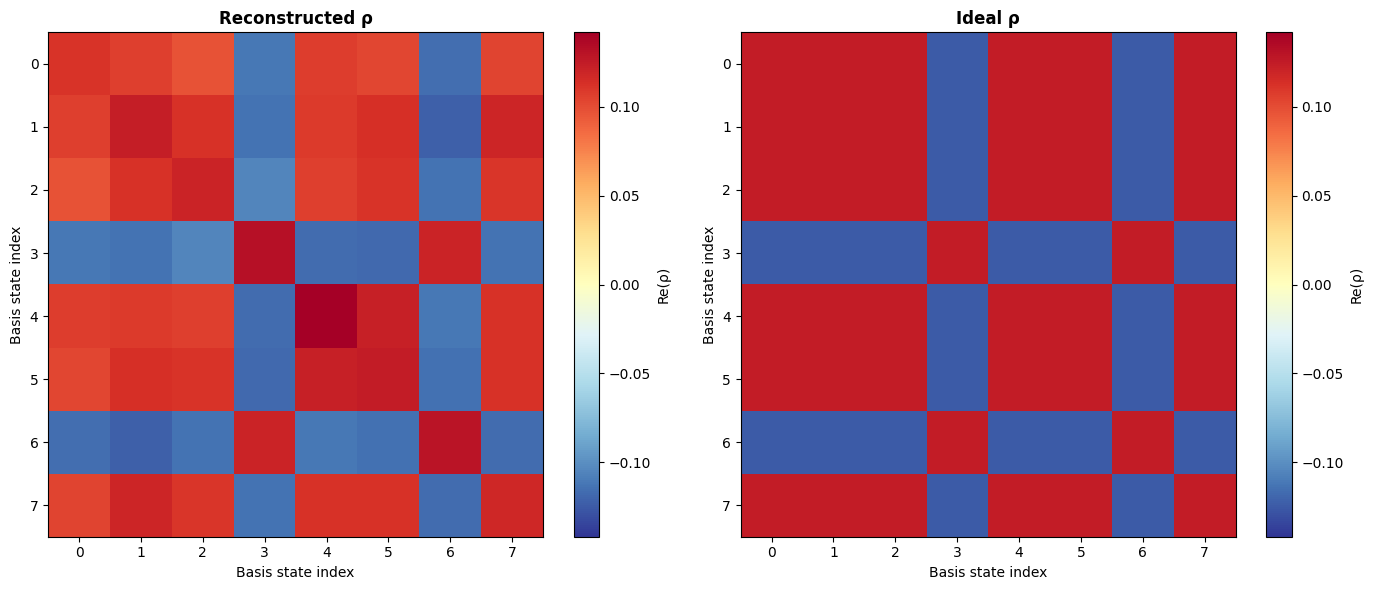


Reconstruction Quality Metrics
Fidelity (Tr[ρ_recon @ ρ_ideal]): 0.908458
Frobenius distance: 0.118553
Purity (reconstructed): 0.830971+0.000000j
Purity (ideal): 1.000000+0.000000j


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Symmetric colorbar limits
rho_real_recon = np.real(rho_recon)
rho_real_ideal = np.real(rho_ideal)
max_abs = max(np.max(np.abs(rho_real_recon)), np.max(np.abs(rho_real_ideal)))
vmin, vmax = -max_abs, max_abs

# Reconstructed
im0 = axes[0].imshow(rho_real_recon, cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)
axes[0].set_title('Reconstructed ρ', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Basis state index')
axes[0].set_ylabel('Basis state index')
cbar0 = plt.colorbar(im0, ax=axes[0])
cbar0.set_label('Re(ρ)')

# Ideal
im1 = axes[1].imshow(rho_real_ideal, cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)
axes[1].set_title('Ideal ρ', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Basis state index')
axes[1].set_ylabel('Basis state index')
cbar1 = plt.colorbar(im1, ax=axes[1])
cbar1.set_label('Re(ρ)')

plt.tight_layout()
plt.show()

# Compute metrics
fidelity = np.real(np.trace(rho_recon @ rho_ideal))
distance_fro = np.linalg.norm(rho_recon - rho_ideal, 'fro')

print(f"\n{'='*60}")
print(f"Reconstruction Quality Metrics")
print(f"{'='*60}")
print(f"Fidelity (Tr[ρ_recon @ ρ_ideal]): {fidelity:.6f}")
print(f"Frobenius distance: {distance_fro:.6f}")
print(f"Purity (reconstructed): {np.trace(rho_recon @ rho_recon):.6f}")
print(f"Purity (ideal): {np.trace(rho_ideal @ rho_ideal):.6f}")
print(f"{'='*60}")

## 6. Detailed Off-Diagonal Analysis

Reconstructing density matrices at different shot counts...
    100 shots: fidelity = 0.404100
    250 shots: fidelity = 0.597851
   1000 shots: fidelity = 0.727848
  10000 shots: fidelity = 0.891909
  10000 shots: fidelity = 0.891909


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_61372/3724938164.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])



Convergence Summary
    100 shots: Fidelity = 0.404100
    250 shots: Fidelity = 0.597851
   1000 shots: Fidelity = 0.727848
  10000 shots: Fidelity = 0.891909


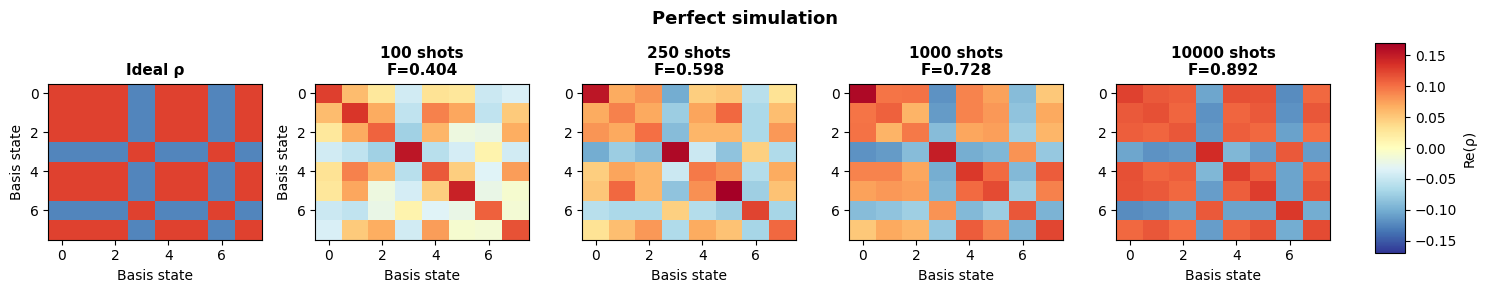

In [20]:
# ── Convergence Analysis: Reconstruction Quality vs. Shot Count ────────────────
"""
Reconstruct density matrix at different shot counts to visualize convergence.
Compare reconstructions at 200, 500, 1000, and 5000 shots against ideal ρ.
"""

shot_counts = [100, 250, 1000, 10000]
reconstructions = {}
fidelities = {}

print("Reconstructing density matrices at different shot counts...")
for n_shots in shot_counts:
    rho = processor.reconstruct(
        feedback_shadows[:n_shots],
        project=True,
        regularization=0.01,
    )
    reconstructions[n_shots] = rho
    fidelity = np.real(np.trace(rho @ rho_ideal))
    fidelities[n_shots] = fidelity
    print(f"  {n_shots:5d} shots: fidelity = {fidelity:.6f}")

# Create 5-panel figure: Ideal + reconstructions at 200, 500, 1000, 5000 shots
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Determine symmetric colorbar scale across all matrices
all_matrices = [rho_ideal] + [reconstructions[n] for n in shot_counts]
max_abs = max(np.max(np.abs(np.real(rho))) for rho in all_matrices)
vmin, vmax = -max_abs, max_abs

# Plot ideal (first panel)
rho_real_ideal = np.real(rho_ideal)
im = axes[0].imshow(rho_real_ideal, cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)
axes[0].set_title('Ideal ρ', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Basis state')
axes[0].set_ylabel('Basis state')

# Plot reconstructions (panels 2-5)
for idx, n_shots in enumerate(shot_counts, start=1):
    rho_recon = reconstructions[n_shots]
    rho_real_recon = np.real(rho_recon)
    
    im = axes[idx].imshow(rho_real_recon, cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)
    fid = fidelities[n_shots]
    axes[idx].set_title(f'{n_shots} shots\nF={fid:.3f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Basis state')
    if idx == 1:
        axes[idx].set_ylabel('Basis state')

# Add single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])


cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Re(ρ)', fontsize=10)

plt.suptitle(f'Perfect simulation', fontsize=13, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("shadow_convergence_sim.png", dpi=300)

print("\n" + "="*60)
print("Convergence Summary")
print("="*60)
for n_shots in shot_counts:
    fid = fidelities[n_shots]
    print(f"  {n_shots:5d} shots: Fidelity = {fid:.6f}")
print("="*60)


Computing convergence metrics for shot counts: [100, 193, 372, 719, 1389, 2682, 5179, 10000]
     100 shots -> fidelity=0.404100, purity=0.310555, K1=0.3306, K2=0.2028, K3=0.3782, XXX=-0.3412
     193 shots -> fidelity=0.519010, purity=0.380827, K1=0.4892, K2=0.4677, K3=0.5389, XXX=-0.1423
     372 shots -> fidelity=0.598247, purity=0.442204, K1=0.5424, K2=0.6001, K3=0.6396, XXX=-0.0689
     719 shots -> fidelity=0.710206, purity=0.549876, K1=0.6266, K2=0.7506, K3=0.7369, XXX=-0.0935
    1389 shots -> fidelity=0.779653, purity=0.640659, K1=0.7529, K2=0.7768, K3=0.8112, XXX=-0.0872
    1389 shots -> fidelity=0.779653, purity=0.640659, K1=0.7529, K2=0.7768, K3=0.8112, XXX=-0.0872
    2682 shots -> fidelity=0.841172, purity=0.725149, K1=0.8082, K2=0.8379, K3=0.8539, XXX=-0.0470
    2682 shots -> fidelity=0.841172, purity=0.725149, K1=0.8082, K2=0.8379, K3=0.8539, XXX=-0.0470
    5179 shots -> fidelity=0.876784, purity=0.778802, K1=0.8963, K2=0.8813, K3=0.8940, XXX=-0.0370
    5179 shots -

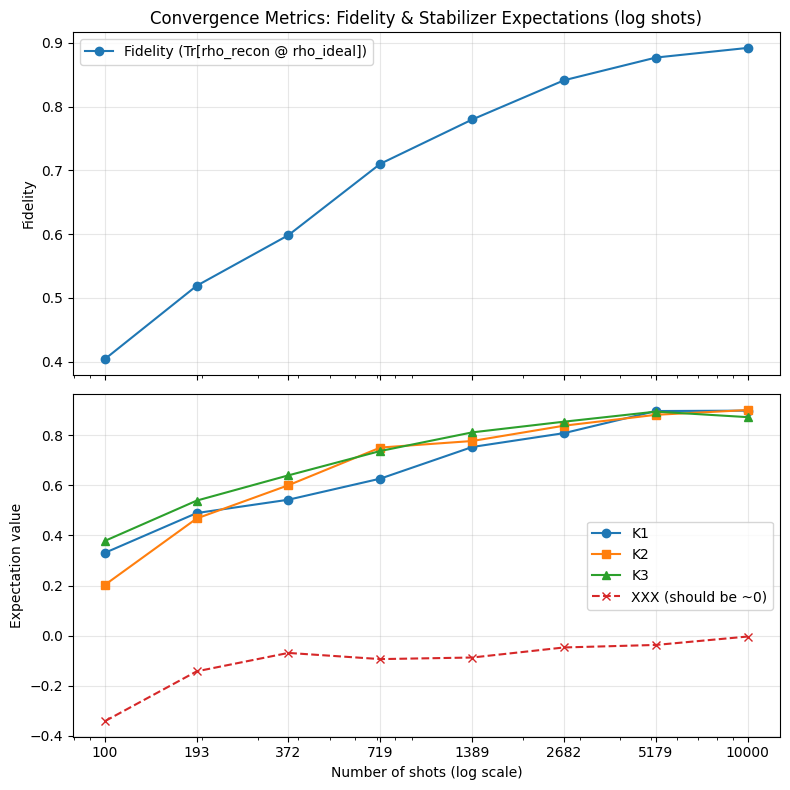

Saved convergence metrics to data/mock_convergence_metrics.npz


In [13]:
# ── Compute and save convergence metrics: fidelity, purity, stabilizers, and a zero Pauli (XXX) ─────────
"""
Compute fidelity, purity and expectation values for the 3-qubit cluster stabilizers and the Pauli 'XXX'
as a function of shot count. Use log-spaced shot counts and plot with a log x-axis.
Save numeric data to disk (now including fidelities).
"""
import os
from pathlib import Path

# shot counts to evaluate (log-spaced between 10^2 and 10^4)
shot_counts = np.unique(np.logspace(2, 4, num=8, dtype=int)).tolist()

# Prepare arrays to hold metrics
fidelities = []
purities = []
stab_expectations = {"K1": [], "K2": [], "K3": []}
xxx_expectations = []

# Define Pauli matrices
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# Helper to build n-qubit operator via Kronecker
from functools import reduce
from operator import mul

def kron_n(*ops):
    return reduce(lambda a, b: np.kron(a, b), ops)

# Cluster stabilizers for 3-qubit linear cluster
K1 = kron_n(X, Z, I)
K2 = kron_n(Z, X, Z)
K3 = kron_n(I, Z, X)

# Representative Pauli expected to be near zero: XXX
XXX = kron_n(X, X, X)

print("Computing convergence metrics for shot counts:", shot_counts)
for n_shots in shot_counts:
    # Choose which shadow buffer to use: prefer feedback_shadows (simulation) if present
    if 'feedback_shadows' in globals():
        buffer = feedback_shadows[:n_shots]
    else:
        buffer = shadow_buffer[:n_shots]

    # Reconstruct
    rho = processor.reconstruct(buffer, project=True, regularization=0.01)

    # Fidelity (vs analytical ideal)
    fid = np.real(np.trace(rho @ rho_ideal))
    fidelities.append(fid)

    # Purity
    purity = np.real(np.trace(rho @ rho))
    purities.append(purity)

    # Stabilizer expectations
    e1 = np.real(np.trace(rho @ K1))
    e2 = np.real(np.trace(rho @ K2))
    e3 = np.real(np.trace(rho @ K3))
    stab_expectations["K1"].append(e1)
    stab_expectations["K2"].append(e2)
    stab_expectations["K3"].append(e3)

    # XXX expectation
    exxx = np.real(np.trace(rho @ XXX))
    xxx_expectations.append(exxx)

    print(f"  {n_shots:6d} shots -> fidelity={fid:.6f}, purity={purity:.6f}, K1={e1:.4f}, K2={e2:.4f}, K3={e3:.4f}, XXX={exxx:.4f}")

# Plot metrics with log x-axis
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Fidelity (top)
ax[0].plot(shot_counts, fidelities, marker='o', label='Fidelity (Tr[rho_recon @ rho_ideal])')
ax[0].set_xscale('log')
ax[0].set_xticks(shot_counts)
ax[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[0].set_ylabel('Fidelity')
ax[0].set_title('Convergence Metrics: Fidelity & Stabilizer Expectations (log shots)')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Stabilizers and XXX (bottom)
ax[1].plot(shot_counts, stab_expectations['K1'], marker='o', label='K1')
ax[1].plot(shot_counts, stab_expectations['K2'], marker='s', label='K2')
ax[1].plot(shot_counts, stab_expectations['K3'], marker='^', label='K3')
ax[1].plot(shot_counts, xxx_expectations, marker='x', linestyle='--', label='XXX (should be ~0)')
ax[1].set_xscale('log')
ax[1].set_xticks(shot_counts)
ax[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[1].set_xlabel('Number of shots (log scale)')
ax[1].set_ylabel('Expectation value')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# Save numeric data including fidelities
out_dir = Path('data')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'mock_convergence_metrics.npz'
np.savez(out_path,
         shot_counts=np.array(shot_counts),
         fidelities=np.array(fidelities),
         purities=np.array(purities),
         K1=np.array(stab_expectations['K1']),
         K2=np.array(stab_expectations['K2']),
         K3=np.array(stab_expectations['K3']),
         XXX=np.array(xxx_expectations))
print(f"Saved convergence metrics to {out_path}")


In [21]:
# ── Bootstrap (point-estimate + std) for simulation convergence metrics (optimized) ─────────────
"""
Compute plug-in point estimates (single reconstruction on the full subset for each
shot count) and bootstrap resampling to estimate standard errors.
This optimized version precomputes single-shot snapshot matrices once to
avoid repeated expensive Kronecker products inside the bootstrap loop.
"""
import numpy as np
from pathlib import Path
import pickle

n_boot = 200
rng = np.random.default_rng(123)
regularization = 0.01

out_dir = Path('data')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'mock_convergence_metrics.npz'

# If shot_counts isn't defined earlier, create a default log-spaced grid
try:
    shot_counts
except NameError:
    shot_counts = np.unique(np.logspace(2, 4, num=8, dtype=int)).tolist()

print(f"Starting point-estimate + bootstrap (n_boot={n_boot}) for shot counts: {shot_counts}")

# Operators (reuse existing K1,K2,K3,XXX if present)
try:
    K1; K2; K3; XXX
except NameError:
    from functools import reduce
    def kron_n(*ops):
        return reduce(lambda a, b: np.kron(a, b), ops)
    I = np.array([[1,0],[0,1]], dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    K1 = kron_n(X, Z, I)
    K2 = kron_n(Z, X, Z)
    K3 = kron_n(I, Z, X)
    XXX = kron_n(X, X, X)

# Ensure feedback_shadows exists: try kernel, then pickle, then simulate
if 'feedback_shadows' not in globals():
    pkl = out_dir / 'feedback_shadows.pkl'
    if pkl.exists():
        print(f"Loading simulated raw shots from {pkl}")
        with pkl.open('rb') as f:
            payload = pickle.load(f)
        feedback_shadows = payload.get('feedback_shadows', payload.get('shots', None))
        if feedback_shadows is None:
            raise RuntimeError(f"{pkl} found but did not contain 'feedback_shadows' key")
    else:
        # As a last resort, generate simulated shots by calling the simulator function
        if 'simulate_feedback_shadows' in globals():
            print('No feedback_shadows in kernel or pickle found — running simulate_feedback_shadows() to generate raw shots (this may take a moment)')
            feedback_shadows = simulate_feedback_shadows(sv_ideal, n_data, theta1, theta2, n_shots=10000)
            print(f"Simulated {len(feedback_shadows)} shots and assigned to feedback_shadows")
            # Save the raw shots for future runs
            try:
                with pkl.open('wb') as f:
                    pickle.dump({'feedback_shadows': feedback_shadows, 'theta1': theta1, 'theta2': theta2}, f)
                print(f"Saved simulated raw shots to {pkl}")
            except Exception as e:
                print(f"Warning: failed to save feedback_shadows pickle: {e}")
        else:
            raise RuntimeError('feedback_shadows not in kernel and data/feedback_shadows.pkl not found, and simulate_feedback_shadows() is not available — run the simulation cell before bootstrapping')

max_shots_avail = len(feedback_shadows)
print(f"Available simulated shots: {max_shots_avail}")

# Precompute single-shot snapshot matrices to avoid repeated kron operations
print('Precomputing single-shot snapshot matrices (this accelerates bootstrap significantly)')
snapshots = [processor._snapshot(basis, outcome) for basis, outcome in feedback_shadows]
print(f'Precomputed {len(snapshots)} snapshot matrices of shape {snapshots[0].shape}')

# Helper: project density matrix to valid PSD, trace-1
def _project_dm(rho):
    rho = (rho + rho.conj().T) / 2
    vals, vecs = np.linalg.eigh(rho)
    vals = np.maximum(vals, 0.0)
    s = vals.sum()
    if s > 1e-12:
        vals /= s
    return vecs @ np.diag(vals) @ vecs.conj().T

# Containers
fidelities = []
fidelities_std = []
purities = []
purities_std = []
K1_vals = []; K1_std = []
K2_vals = []; K2_std = []
K3_vals = []; K3_std = []
XXX_vals = []; XXX_std = []

# Precompute identity for regularization
dim = snapshots[0].shape[0]
mixed = np.eye(dim, dtype=complex) / dim

for n_shots in shot_counts:
    if n_shots > max_shots_avail:
        raise ValueError(f"Requested {n_shots} shots but only {max_shots_avail} available in feedback_shadows")

    # --- Plug-in point estimate using the first n_shots (average snapshots) ---
    rho_avg = sum(snapshots[:n_shots]) / float(n_shots)
    # Apply regularization
    rho_reg = (1 - regularization) * rho_avg + regularization * mixed
    rho_full = _project_dm(rho_reg)

    fid_point = np.real(np.trace(rho_full @ rho_ideal))
    pur_point = np.real(np.trace(rho_full @ rho_full))
    e1_point = np.real(np.trace(rho_full @ K1))
    e2_point = np.real(np.trace(rho_full @ K2))
    e3_point = np.real(np.trace(rho_full @ K3))
    exxx_point = np.real(np.trace(rho_full @ XXX))

    fidelities.append(fid_point)
    purities.append(pur_point)
    K1_vals.append(e1_point); K2_vals.append(e2_point); K3_vals.append(e3_point)
    XXX_vals.append(exxx_point)

    # --- Bootstrap resampling to estimate std (sample snapshots and average) ---
    fid_samps = []
    pur_samps = []
    k1_samps = []
    k2_samps = []
    k3_samps = []
    xxx_samps = []

    for b in range(n_boot):
        idxs = rng.integers(0, max_shots_avail, size=n_shots)
        # Average selected snapshot matrices
        rho_b_avg = sum(snapshots[i] for i in idxs) / float(n_shots)
        rho_b_reg = (1 - regularization) * rho_b_avg + regularization * mixed
        rho_b = _project_dm(rho_b_reg)

        fid_samps.append(np.real(np.trace(rho_b @ rho_ideal)))
        pur_samps.append(np.real(np.trace(rho_b @ rho_b)))
        k1_samps.append(np.real(np.trace(rho_b @ K1)))
        k2_samps.append(np.real(np.trace(rho_b @ K2)))
        k3_samps.append(np.real(np.trace(rho_b @ K3)))
        xxx_samps.append(np.real(np.trace(rho_b @ XXX)))

    fidelities_std.append(np.std(fid_samps, ddof=1))
    purities_std.append(np.std(pur_samps, ddof=1))
    K1_std.append(np.std(k1_samps, ddof=1))
    K2_std.append(np.std(k2_samps, ddof=1))
    K3_std.append(np.std(k3_samps, ddof=1))
    XXX_std.append(np.std(xxx_samps, ddof=1))

    print(f"Completed {n_shots} shots: fid={fid_point:.4f} ± {fidelities_std[-1]:.4f}")

# Convert to arrays and save (overwrite existing NPZ with point estimates + stds)
np.savez(out_path,
         shot_counts=np.array(shot_counts),
         fidelities=np.array(fidelities), fidelities_std=np.array(fidelities_std),
         purities=np.array(purities), purities_std=np.array(purities_std),
         K1=np.array(K1_vals), K1_std=np.array(K1_std),
         K2=np.array(K2_vals), K2_std=np.array(K2_std),
         K3=np.array(K3_vals), K3_std=np.array(K3_std),
         XXX=np.array(XXX_vals), XXX_std=np.array(XXX_std))

print(f"Saved point-estimate + bootstrap-std mock convergence metrics to {out_path}")

# Quick verification: load and list keys
d = np.load(out_path)
print('Saved keys:', d.files)
for k in d.files:
    print(f"  {k}: shape={d[k].shape}")


Starting point-estimate + bootstrap (n_boot=200) for shot counts: [100, 250, 1000, 10000]
Available simulated shots: 10000
Precomputing single-shot snapshot matrices (this accelerates bootstrap significantly)
Precomputed 10000 snapshot matrices of shape (8, 8)
Completed 100 shots: fid=0.4041 ± 0.0578
Precomputed 10000 snapshot matrices of shape (8, 8)
Completed 100 shots: fid=0.4041 ± 0.0578
Completed 250 shots: fid=0.5979 ± 0.0476
Completed 250 shots: fid=0.5979 ± 0.0476
Completed 1000 shots: fid=0.7278 ± 0.0313
Completed 1000 shots: fid=0.7278 ± 0.0313
Completed 10000 shots: fid=0.8919 ± 0.0129
Saved point-estimate + bootstrap-std mock convergence metrics to data/mock_convergence_metrics.npz
Saved keys: ['shot_counts', 'fidelities', 'fidelities_std', 'purities', 'purities_std', 'K1', 'K1_std', 'K2', 'K2_std', 'K3', 'K3_std', 'XXX', 'XXX_std']
  shot_counts: shape=(4,)
  fidelities: shape=(4,)
  fidelities_std: shape=(4,)
  purities: shape=(4,)
  purities_std: shape=(4,)
  K1: shape=(

Off-diagonal element analysis:
Basis states: 8

  ΔHamming = 0: recon_mean=0.129975, ideal_mean=0.125000
  ΔHamming = 1: recon_mean=0.123129, ideal_mean=0.125000
  ΔHamming = 2: recon_mean=0.128341, ideal_mean=0.125000
  ΔHamming = 3: recon_mean=0.123960, ideal_mean=0.125000


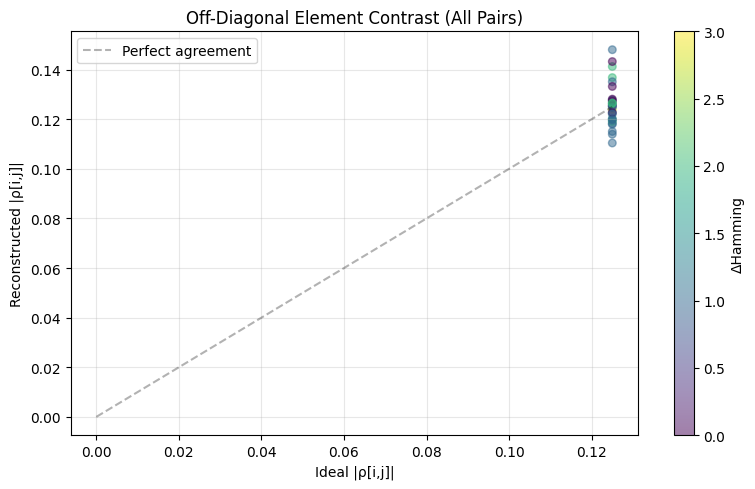

In [46]:
# Extract off-diagonal elements
dim = 2 ** n_data

# Compute Hamming weights for basis state labels
hamming_weights = [bin(i).count('1') for i in range(dim)]

print(f"Off-diagonal element analysis:")
print(f"Basis states: {dim}\n")

off_diag_recon = []
off_diag_ideal = []
hamming_pairs = []

for i in range(dim):
    for j in range(i+1, dim):
        off_diag_recon.append(np.abs(rho_real_recon[i, j]))
        off_diag_ideal.append(np.abs(rho_real_ideal[i, j]))
        hamming_pairs.append(abs(hamming_weights[i] - hamming_weights[j]))

off_diag_recon = np.array(off_diag_recon)
off_diag_ideal = np.array(off_diag_ideal)
hamming_pairs = np.array(hamming_pairs)

# Group by Hamming weight difference
for dh in sorted(np.unique(hamming_pairs)):
    mask = hamming_pairs == dh
    mean_recon = np.mean(off_diag_recon[mask])
    mean_ideal = np.mean(off_diag_ideal[mask])
    print(f"  ΔHamming = {dh}: recon_mean={mean_recon:.6f}, ideal_mean={mean_ideal:.6f}")

# Scatter plot: off-diagonal contrast
plt.figure(figsize=(8, 5))
plt.scatter(off_diag_ideal, off_diag_recon, alpha=0.5, c=hamming_pairs, cmap='viridis', s=30)
plt.xlabel('Ideal |ρ[i,j]|')
plt.ylabel('Reconstructed |ρ[i,j]|')
plt.title('Off-Diagonal Element Contrast (All Pairs)')
cbar = plt.colorbar(label='ΔHamming')
plt.plot([0, max(off_diag_ideal)], [0, max(off_diag_ideal)], 'k--', alpha=0.3, label='Perfect agreement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Check Channel Inversion Operator (Debugging)

In [10]:
# Verify that the shadow snapshot operator is correctly inverted
# Sample one shot and manually compute what the shadow snapshot operator looks like

test_shot = feedback_shadows[0]
basis_labels, outcomes = test_shot

print(f"Test shot: basis={basis_labels}, outcome={outcomes}")
print()

# Manually compute the snapshot for this shot using processor's internal method
snapshot = processor._snapshot(basis_labels, outcomes)

print(f"Snapshot operator shape: {snapshot.shape}")
print(f"Snapshot trace: {np.trace(snapshot):.6f}")
print()

# Check a few diagonal and off-diagonal elements
print("Sample diagonal elements of snapshot:")
for i in range(min(3, dim)):
    print(f"  snapshot[{i},{i}] = {np.real(snapshot[i,i]):.6f}")

print("\nSample off-diagonal elements:")
for i in range(min(2, dim)):
    for j in range(i+1, min(i+3, dim)):
        print(f"  snapshot[{i},{j}] = {np.real(snapshot[i,j]):.6f}")

Test shot: basis=['Y', 'Y', 'Y'], outcome=[0, 1, 1]

Snapshot operator shape: (8, 8)
Snapshot trace: 1.000000+0.000000j

Sample diagonal elements of snapshot:
  snapshot[0,0] = 0.125000
  snapshot[1,1] = 0.125000
  snapshot[2,2] = 0.125000

Sample off-diagonal elements:
  snapshot[0,1] = 0.000000
  snapshot[0,2] = 0.000000
  snapshot[1,2] = 1.125000
  snapshot[1,3] = 0.000000
